In [3]:
from pathlib import Path

import pandas as pd


# Detect the project root from the current working directory
current_path = Path.cwd().resolve()
project_candidates = (current_path, *current_path.parents)

PROJECT_ROOT = next(
    (
        path
        for path in project_candidates
        if (path / "requirements.txt").is_file()
        and (path / "notebooks").is_dir()
        and (path / "data").is_dir()
    ),
    None,
)

assert PROJECT_ROOT is not None, (
    "The project root could not be detected from the current directory."
)

ARTIFACT_PATHS = {
    "analytical_table": (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "pass_rush_analytical_table.parquet"
    ),
    "column_inventory": (
        PROJECT_ROOT
        / "reports"
        / "analytical_table_column_inventory.csv"
    ),
    "quality_report": (
        PROJECT_ROOT
        / "reports"
        / "analytical_table_quality_report.csv"
    ),
}

artifact_check = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "relative_path": artifact_path.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "exists": artifact_path.is_file(),
        }
        for artifact_name, artifact_path in ARTIFACT_PATHS.items()
    ]
)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(artifact_check)

assert artifact_check["exists"].all(), (
    "At least one required Stage 4 artifact is missing."
)

PROJECT_ROOT: C:\Users\yvett\OneDrive\Documentos\Francisco Fonseca\nfl-pressure-prediction
           artifact                                      relative_path  exists
0  analytical_table  data/processed/pass_rush_analytical_table.parquet    True
1  column_inventory      reports/analytical_table_column_inventory.csv    True
2    quality_report        reports/analytical_table_quality_report.csv    True


In [5]:
# Load the validated Stage 4 artifacts from disk
analytical_table = pd.read_parquet(
    ARTIFACT_PATHS["analytical_table"]
)

column_inventory = pd.read_csv(
    ARTIFACT_PATHS["column_inventory"]
)

quality_report = pd.read_csv(
    ARTIFACT_PATHS["quality_report"]
)

load_summary = pd.DataFrame(
    [
        {
            "artifact": "analytical_table",
            "rows": analytical_table.shape[0],
            "columns": analytical_table.shape[1],
        },
        {
            "artifact": "column_inventory",
            "rows": column_inventory.shape[0],
            "columns": column_inventory.shape[1],
        },
        {
            "artifact": "quality_report",
            "rows": quality_report.shape[0],
            "columns": quality_report.shape[1],
        },
    ]
)

print(load_summary)

           artifact   rows  columns
0  analytical_table  36259       70
1  column_inventory     70        7
2    quality_report     12        4


In [8]:
# Define column roles from the validated Stage 4 contract
identifier_columns = [
    "gameId",
    "playId",
    "pass_rusher_nfl_id",
    "quarterback_nfl_id",
    "nearest_blocker_nfl_id",
]

split_columns = ["actual_week"]

audit_columns = [
    "original_play_direction",
    "rusher_x",
    "rusher_y",
    "rusher_orientation",
    "rusher_direction",
    "quarterback_x",
    "quarterback_orientation",
    "quarterback_direction",
    "nearest_blocker_x",
    "nearest_blocker_y",
    "nearest_blocker_orientation",
    "nearest_blocker_direction",
]

target_column = "pressure"
categorical_predictor_columns = ["rusher_position_lined_up"]

non_predictor_columns = (
    identifier_columns
    + split_columns
    + audit_columns
    + [target_column]
)

predictor_columns = [
    column
    for column in analytical_table.columns
    if column not in non_predictor_columns
]

numeric_predictor_columns = [
    column
    for column in predictor_columns
    if column not in categorical_predictor_columns
]

analytical_key = ["gameId", "playId", "pass_rusher_nfl_id"]

unique_play_count = (
    analytical_table[["gameId", "playId"]]
    .drop_duplicates()
    .shape[0]
)

quality_pass_count = (
    quality_report["status"]
    .astype(str)
    .str.upper()
    .eq("PASS")
    .sum()
)

contract_checks = pd.DataFrame(
    [
        {
            "check": "Table shape",
            "expected": "36259 x 70",
            "observed": (
                f"{analytical_table.shape[0]} x "
                f"{analytical_table.shape[1]}"
            ),
            "passed": analytical_table.shape == (36_259, 70),
        },
        {
            "check": "Duplicate analytical keys",
            "expected": "0",
            "observed": analytical_table.duplicated(
                analytical_key
            ).sum(),
            "passed": not analytical_table.duplicated(
                analytical_key
            ).any(),
        },
        {
            "check": "Unique modeling plays",
            "expected": "8531",
            "observed": unique_play_count,
            "passed": unique_play_count == 8_531,
        },
        {
            "check": "Missing values",
            "expected": "0",
            "observed": analytical_table.isna().sum().sum(),
            "passed": not analytical_table.isna().any().any(),
        },
        {
            "check": "Positive targets",
            "expected": "4214",
            "observed": int(analytical_table[target_column].sum()),
            "passed": analytical_table[target_column].sum() == 4_214,
        },
        {
            "check": "Actual weeks",
            "expected": "1 to 8",
            "observed": (
                f"{analytical_table['actual_week'].min()} to "
                f"{analytical_table['actual_week'].max()}"
            ),
            "passed": set(
                analytical_table["actual_week"].unique()
            ) == set(range(1, 9)),
        },
        {
            "check": "Eligible predictors",
            "expected": "50 numeric + 1 categorical",
            "observed": (
                f"{len(numeric_predictor_columns)} numeric + "
                f"{len(categorical_predictor_columns)} categorical"
            ),
            "passed": (
                len(numeric_predictor_columns) == 50
                and len(categorical_predictor_columns) == 1
            ),
        },
        {
            "check": "Stage 4 quality checks",
            "expected": "12 PASS",
            "observed": f"{quality_pass_count} PASS",
            "passed": quality_pass_count == 12,
        },
    ]
)

contract_checks["status"] = contract_checks["passed"].map(
    {True: "PASS", False: "FAIL"}
)

display(contract_checks.drop(columns="passed"))

assert contract_checks["passed"].all(), (
    "The analytical contract validation failed."
)

,check,expected,observed,status
0,Table shape,36259 x 70,36259 x 70,PASS
1,Duplicate analytical keys,0,0,PASS
2,Unique modeling plays,8531,8531,PASS
3,Missing values,0,0,PASS
4,Positive targets,4214,4214,PASS
5,Actual weeks,1 to 8,1 to 8,PASS
6,Eligible predictors,50 numeric + 1 categorical,50 numeric + 1 categorical,PASS
7,Stage 4 quality checks,12 PASS,12 PASS,PASS


,pressure,class,rows,percentage
0,0,No pressure,32045,88.378
1,1,Pressure,4214,11.622


,actual_week,pass_rush_rows,negatives,positives,pressure_rate_pct
0,1,4988,4390,598,11.989
1,2,4498,3977,521,11.583
2,3,4809,4203,606,12.601
3,4,4733,4176,557,11.768
4,5,4681,4153,528,11.280
5,6,4241,3768,473,11.153
6,7,3865,3438,427,11.048
7,8,4444,3940,504,11.341


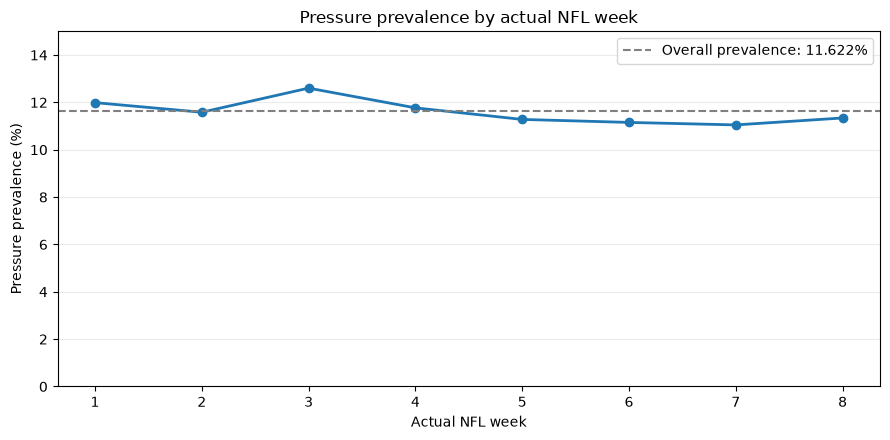

In [9]:
import matplotlib.pyplot as plt


# Summarize the target distribution
target_summary = (
    analytical_table[target_column]
    .value_counts()
    .sort_index()
    .rename_axis("pressure")
    .reset_index(name="rows")
)

target_summary["class"] = target_summary["pressure"].map(
    {0: "No pressure", 1: "Pressure"}
)

target_summary["percentage"] = (
    100 * target_summary["rows"] / len(analytical_table)
)

target_summary = target_summary[
    ["pressure", "class", "rows", "percentage"]
]


# Summarize target stability by actual NFL week
weekly_target_summary = (
    analytical_table
    .groupby("actual_week", as_index=False)
    .agg(
        pass_rush_rows=(target_column, "size"),
        positives=(target_column, "sum"),
        pressure_rate=(target_column, "mean"),
    )
)

weekly_target_summary["negatives"] = (
    weekly_target_summary["pass_rush_rows"]
    - weekly_target_summary["positives"]
)

weekly_target_summary["pressure_rate_pct"] = (
    100 * weekly_target_summary["pressure_rate"]
)

weekly_target_summary = weekly_target_summary[
    [
        "actual_week",
        "pass_rush_rows",
        "negatives",
        "positives",
        "pressure_rate_pct",
    ]
]

overall_pressure_rate = (
    100 * analytical_table[target_column].mean()
)

display(target_summary.round({"percentage": 3}))
display(
    weekly_target_summary.round(
        {"pressure_rate_pct": 3}
    )
)


# Plot weekly target prevalence
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(
    weekly_target_summary["actual_week"],
    weekly_target_summary["pressure_rate_pct"],
    marker="o",
    linewidth=2,
)

ax.axhline(
    overall_pressure_rate,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall prevalence: {overall_pressure_rate:.3f}%",
)

ax.set_title("Pressure prevalence by actual NFL week")
ax.set_xlabel("Actual NFL week")
ax.set_ylabel("Pressure prevalence (%)")
ax.set_xticks(weekly_target_summary["actual_week"])
ax.set_ylim(0, 15)
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [11]:
import numpy as np


# Summarize the categorical predictor
position_summary = (
    analytical_table
    .groupby(
        "rusher_position_lined_up",
        as_index=False,
        observed=True,
    )
    .agg(
        pass_rush_rows=(target_column, "size"),
        positives=(target_column, "sum"),
        pressure_rate=(target_column, "mean"),
    )
)

position_summary["dataset_share_pct"] = (
    100
    * position_summary["pass_rush_rows"]
    / len(analytical_table)
)

position_summary["pressure_rate_pct"] = (
    100 * position_summary["pressure_rate"]
)

position_summary = (
    position_summary[
        [
            "rusher_position_lined_up",
            "pass_rush_rows",
            "dataset_share_pct",
            "positives",
            "pressure_rate_pct",
        ]
    ]
    .sort_values("pass_rush_rows", ascending=False)
    .reset_index(drop=True)
)


# Screen numeric predictors without selecting or removing features
numeric_screening_records = []

for feature in numeric_predictor_columns:
    values = analytical_table[feature]

    no_pressure_values = analytical_table.loc[
        analytical_table[target_column] == 0,
        feature,
    ]

    pressure_values = analytical_table.loc[
        analytical_table[target_column] == 1,
        feature,
    ]

    first_quartile = values.quantile(0.25)
    third_quartile = values.quantile(0.75)
    interquartile_range = third_quartile - first_quartile

    if interquartile_range > 0:
        lower_bound = first_quartile - 1.5 * interquartile_range
        upper_bound = third_quartile + 1.5 * interquartile_range

        outlier_rate_pct = (
            100
            * (
                (values < lower_bound)
                | (values > upper_bound)
            ).mean()
        )
    else:
        outlier_rate_pct = np.nan

    pooled_variance = (
        (
            (len(no_pressure_values) - 1)
            * no_pressure_values.var(ddof=1)
        )
        + (
            (len(pressure_values) - 1)
            * pressure_values.var(ddof=1)
        )
    ) / (
        len(no_pressure_values)
        + len(pressure_values)
        - 2
    )

    pooled_standard_deviation = np.sqrt(pooled_variance)

    standardized_difference = (
        (
            pressure_values.mean()
            - no_pressure_values.mean()
        )
        / pooled_standard_deviation
        if pooled_standard_deviation > 0
        else 0.0
    )

    numeric_screening_records.append(
        {
            "feature": feature,
            "median": values.median(),
            "iqr": interquartile_range,
            "outlier_rate_pct": outlier_rate_pct,
            "mean_no_pressure": no_pressure_values.mean(),
            "mean_pressure": pressure_values.mean(),
            "standardized_difference": standardized_difference,
            "absolute_standardized_difference": abs(
                standardized_difference
            ),
        }
    )

numeric_screening = (
    pd.DataFrame(numeric_screening_records)
    .sort_values(
        "absolute_standardized_difference",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(position_summary.round(3))
print(numeric_screening.head(12).round(3))

   rusher_position_lined_up  pass_rush_rows  dataset_share_pct  positives  \
0                       DRT            4744             13.084        380   
1                       LEO            4590             12.659        622   
2                       DLT            4312             11.892        353   
3                       REO            4215             11.625        520   
4                      ROLB            4027             11.106        477   
5                      LOLB            3827             10.555        579   
6                        LE            3173              8.751        353   
7                        RE            2360              6.509        256   
8                        NT            1243              3.428        122   
9                       NRT             741              2.044         42   
10                      NLT             588              1.622         43   
11                     RILB             561              1.547         91   

In [12]:
# Calculate predictor-only Spearman correlations
spearman_correlation = analytical_table[
    numeric_predictor_columns
].corr(method="spearman")

upper_triangle_mask = np.triu(
    np.ones(spearman_correlation.shape),
    k=1,
).astype(bool)

correlation_pairs = (
    spearman_correlation
    .where(upper_triangle_mask)
    .stack()
    .rename("spearman_correlation")
    .reset_index()
    .rename(
        columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
        }
    )
)

correlation_pairs["absolute_correlation"] = (
    correlation_pairs["spearman_correlation"].abs()
)

correlation_pairs = (
    correlation_pairs
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

correlation_threshold_summary = pd.DataFrame(
    [
        {
            "absolute_threshold": threshold,
            "correlated_pairs": int(
                (
                    correlation_pairs[
                        "absolute_correlation"
                    ]
                    >= threshold
                ).sum()
            ),
        }
        for threshold in [0.70, 0.80, 0.90, 0.95]
    ]
)

print(correlation_threshold_summary)
print(correlation_pairs.head(20).round(3))

   absolute_threshold  correlated_pairs
0                0.70                26
1                0.80                13
2                0.90                 2
3                0.95                 0
                                  feature_1  \
0                              rusher_speed   
1                         quarterback_speed   
2                  rusher_qb_lateral_offset   
3                         rusher_velocity_x   
4                     nearest_blocker_speed   
5                 rusher_velocity_toward_qb   
6                      rusher_direction_cos   
7                              rusher_speed   
8            rusher_qb_absolute_lateral_gap   
9                        rusher_qb_distance   
10            nearest_blocker_direction_cos   
11                    nearest_blocker_speed   
12                             rusher_speed   
13           rusher_qb_absolute_lateral_gap   
14  nearest_blocker_absolute_lateral_offset   
15           rusher_qb_absolute_lateral_gap   
1

In [13]:
# Preview the proposed chronological split
split_preview = analytical_table[
    [
        "gameId",
        "playId",
        "actual_week",
        "rusher_position_lined_up",
        target_column,
    ]
].copy()

split_preview["proposed_split"] = np.select(
    [
        split_preview["actual_week"].between(1, 6),
        split_preview["actual_week"].eq(7),
        split_preview["actual_week"].eq(8),
    ],
    [
        "train",
        "validation",
        "test",
    ],
    default="unassigned",
)

assert not split_preview["proposed_split"].eq(
    "unassigned"
).any(), "Some rows were not assigned to a split."

split_preview["proposed_split"] = pd.Categorical(
    split_preview["proposed_split"],
    categories=["train", "validation", "test"],
    ordered=True,
)

split_row_summary = (
    split_preview
    .groupby("proposed_split", observed=True)
    .agg(
        pass_rush_rows=(target_column, "size"),
        positives=(target_column, "sum"),
        pressure_rate=(target_column, "mean"),
    )
)

split_play_summary = (
    split_preview
    .drop_duplicates(
        ["gameId", "playId", "proposed_split"]
    )
    .groupby("proposed_split", observed=True)
    .size()
    .rename("plays")
)

split_week_summary = (
    split_preview
    .groupby("proposed_split", observed=True)["actual_week"]
    .apply(
        lambda values: ", ".join(
            map(str, sorted(values.unique()))
        )
    )
    .rename("actual_weeks")
)

split_summary = (
    split_row_summary
    .join(split_play_summary)
    .join(split_week_summary)
    .reset_index()
)

split_summary["row_share_pct"] = (
    100
    * split_summary["pass_rush_rows"]
    / len(split_preview)
)

split_summary["pressure_rate_pct"] = (
    100 * split_summary["pressure_rate"]
)

split_summary = split_summary[
    [
        "proposed_split",
        "actual_weeks",
        "pass_rush_rows",
        "row_share_pct",
        "plays",
        "positives",
        "pressure_rate_pct",
    ]
]

play_split_counts = (
    split_preview[
        ["gameId", "playId", "proposed_split"]
    ]
    .drop_duplicates()
    .groupby(["gameId", "playId"], observed=True)[
        "proposed_split"
    ]
    .nunique()
)

cross_split_plays = int(
    (play_split_counts > 1).sum()
)

train_positions = set(
    split_preview.loc[
        split_preview["proposed_split"] == "train",
        "rusher_position_lined_up",
    ]
)

category_coverage = pd.DataFrame(
    [
        {
            "split": split_name,
            "unseen_positions_vs_train": sorted(
                set(
                    split_preview.loc[
                        split_preview["proposed_split"]
                        == split_name,
                        "rusher_position_lined_up",
                    ]
                )
                - train_positions
            ),
        }
        for split_name in ["validation", "test"]
    ]
)

print(f"Cross-split plays: {cross_split_plays}")
display(
    split_summary.round(
        {
            "row_share_pct": 3,
            "pressure_rate_pct": 3,
        }
    )
)
display(category_coverage)

assert cross_split_plays == 0, (
    "At least one play appears in multiple splits."
)

Cross-split plays: 0


,proposed_split,actual_weeks,pass_rush_rows,row_share_pct,plays,positives,pressure_rate_pct
0,train,"1, 2, 3, 4, 5, 6",27950,77.084,6587,3283,11.746
1,validation,7,3865,10.659,913,427,11.048
2,test,8,4444,12.256,1031,504,11.341


,split,unseen_positions_vs_train
0,validation,[]
1,test,[]


## Conclusiones de la Etapa 5

### Integridad del dataset

El análisis exploratorio utilizó exclusivamente los artefactos validados de la Etapa 4.

La tabla analítica contiene:

- 36,259 observaciones.
- 8,531 jugadas.
- 70 columnas.
- 50 predictores numéricos.
- 1 predictor categórico.
- Cero llaves analíticas duplicadas.
- Cero valores faltantes.
- Las 12 validaciones de calidad de la Etapa 4 en estado `PASS`.

### Variable objetivo

La variable `pressure` identifica si el defensor produjo un hurry, hit o sack sobre el quarterback.

Se observaron:

- 4,214 presiones, equivalentes al 11.622%.
- 32,045 casos sin presión, equivalentes al 88.378%.

Existe desbalance de clases, con aproximadamente 7.6 negativos por cada positivo. Por ello, la evaluación futura no deberá depender únicamente de accuracy.

La prevalencia semanal permaneció entre 11.048% y 12.601%, sin evidencia de un cambio temporal abrupto durante las semanas 1 a 8.

### Predictores

La tasa de presión cambia según la posición en la que se alinea el defensor. Sin embargo, las tasas extremas de posiciones con pocas observaciones no deben interpretarse como evidencia concluyente.

Ningún predictor numérico mostró una separación individual fuerte entre las clases. Las mayores diferencias estandarizadas estuvieron alrededor de 0.25, lo que sugiere que la presión depende de la combinación de múltiples factores espaciales, físicos y contextuales.

Los valores extremos se conservarán. Ya fueron validados como situaciones plausibles relacionadas con diferentes posiciones, formaciones y tipos de pass rush. No se aplicará clipping ni eliminación automática.

### Redundancia

Entre los 1,225 pares de predictores numéricos:

- 26 presentaron correlación absoluta de Spearman igual o superior a 0.70.
- 13 fueron iguales o superiores a 0.80.
- 2 fueron iguales o superiores a 0.90.
- Ninguno superó 0.95.

Las correlaciones más altas son coherentes con features que describen movimientos o relaciones geométricas similares. No se eliminaron predictores durante el EDA.

### Partición temporal aprobada

| Partición | Semanas | Filas | Jugadas | Positivos | Prevalencia |
|---|---:|---:|---:|---:|---:|
| Train | 1–6 | 27,950 | 6,587 | 3,283 | 11.746% |
| Validation | 7 | 3,865 | 913 | 427 | 11.048% |
| Test | 8 | 4,444 | 1,031 | 504 | 11.341% |

La partición:

- Conserva el orden temporal.
- Mantiene todas las filas de una jugada en la misma partición.
- Presenta cero jugadas compartidas entre conjuntos.
- No contiene posiciones desconocidas en validation o test respecto de train.
- Reserva la semana 8 para la evaluación final.

`gameId`, `playId`, identificadores de jugadores y `actual_week` se conservarán únicamente para trazabilidad, agrupación y partición. Nunca formarán parte de los predictores.

El preprocesamiento futuro deberá ajustarse exclusivamente con train. Validation se utilizará para seleccionar y ajustar modelos, mientras que test permanecerá intacto hasta la evaluación final.

No se entrenaron modelos durante esta etapa.

Missing PFF roles: 0

PFF role distribution:
  pff_role  rows  percentage
  Coverage 57765       30.68
Pass Block 46057       24.47
Pass Route 39513       20.99
 Pass Rush 36362       19.32
      Pass  8557        4.55

PFF role validation: PASSED
